# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [31]:
# import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [32]:
# Load dataset
dataset = '../data/data_student.csv'
df = pd.read_csv(dataset, sep=';')
df.head(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [33]:
# Add column identifier ("Student_ID") to dataset
df.insert(0, 'Student_ID', range(1000001, 1000001 + len(df)))
df.head(5)

,Student_ID,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1000001,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1000002,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1000003,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1000004,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,1000005,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [34]:
# Check the number of missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [35]:
# Check for duplicate data
print('Total duplicate:', df.duplicated().sum())

Total duplicate: 0


In [36]:
# Review the number of rows, columns, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Student_ID                                    4424 non-null   int64  
 1   Marital_status                                4424 non-null   int64  
 2   Application_mode                              4424 non-null   int64  
 3   Application_order                             4424 non-null   int64  
 4   Course                                        4424 non-null   int64  
 5   Daytime_evening_attendance                    4424 non-null   int64  
 6   Previous_qualification                        4424 non-null   int64  
 7   Previous_qualification_grade                  4424 non-null   float64
 8   Nacionality                                   4424 non-null   int64  
 9   Mothers_qualification                         4424 non-null   i

In [37]:
# Check dataset descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,4424.0,1.002212e+06,1277.243125,1000001.00,1001106.75,1.002212e+06,1.003318e+06,1.004424e+06
Marital_status,4424.0,1.178571e+00,0.605747,1.00,1.00,1.000000e+00,1.000000e+00,6.000000e+00
Application_mode,4424.0,1.866908e+01,17.484682,1.00,1.00,1.700000e+01,3.900000e+01,5.700000e+01
Application_order,4424.0,1.727848e+00,1.313793,0.00,1.00,1.000000e+00,2.000000e+00,9.000000e+00
Course,4424.0,8.856643e+03,2063.566416,33.00,9085.00,9.238000e+03,9.556000e+03,9.991000e+03
Daytime_evening_attendance,4424.0,8.908228e-01,0.311897,0.00,1.00,1.000000e+00,1.000000e+00,1.000000e+00
Previous_qualification,4424.0,4.577758e+00,10.216592,1.00,1.00,1.000000e+00,1.000000e+00,4.300000e+01
Previous_qualification_grade,4424.0,1.326133e+02,13.188332,95.00,125.00,1.331000e+02,1.400000e+02,1.900000e+02
Nacionality,4424.0,1.873192e+00,6.914514,1.00,1.00,1.000000e+00,1.000000e+00,1.090000e+02
Mothers_qualification,4424.0,1.956193e+01,15.603186,1.00,2.00,1.900000e+01,3.700000e+01,4.400000e+01


In [38]:
# ==============================================================================
# Split columns into numerical and categorical features
# ==============================================================================

# Define category features
categorical = [
    'Marital_status',
    'Application_mode',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Gender',
    'Age_at_enrollment',
    'Status'
]

categorical_features = [
    col 
    for col in categorical
    if col in df.columns and col != 'Status'
]

exclusions = ['Student_ID', 'Status']


# Define numerical features
numerical_features = [
    col for col in df.columns
    if col not in categorical_features and col not in exclusions
]

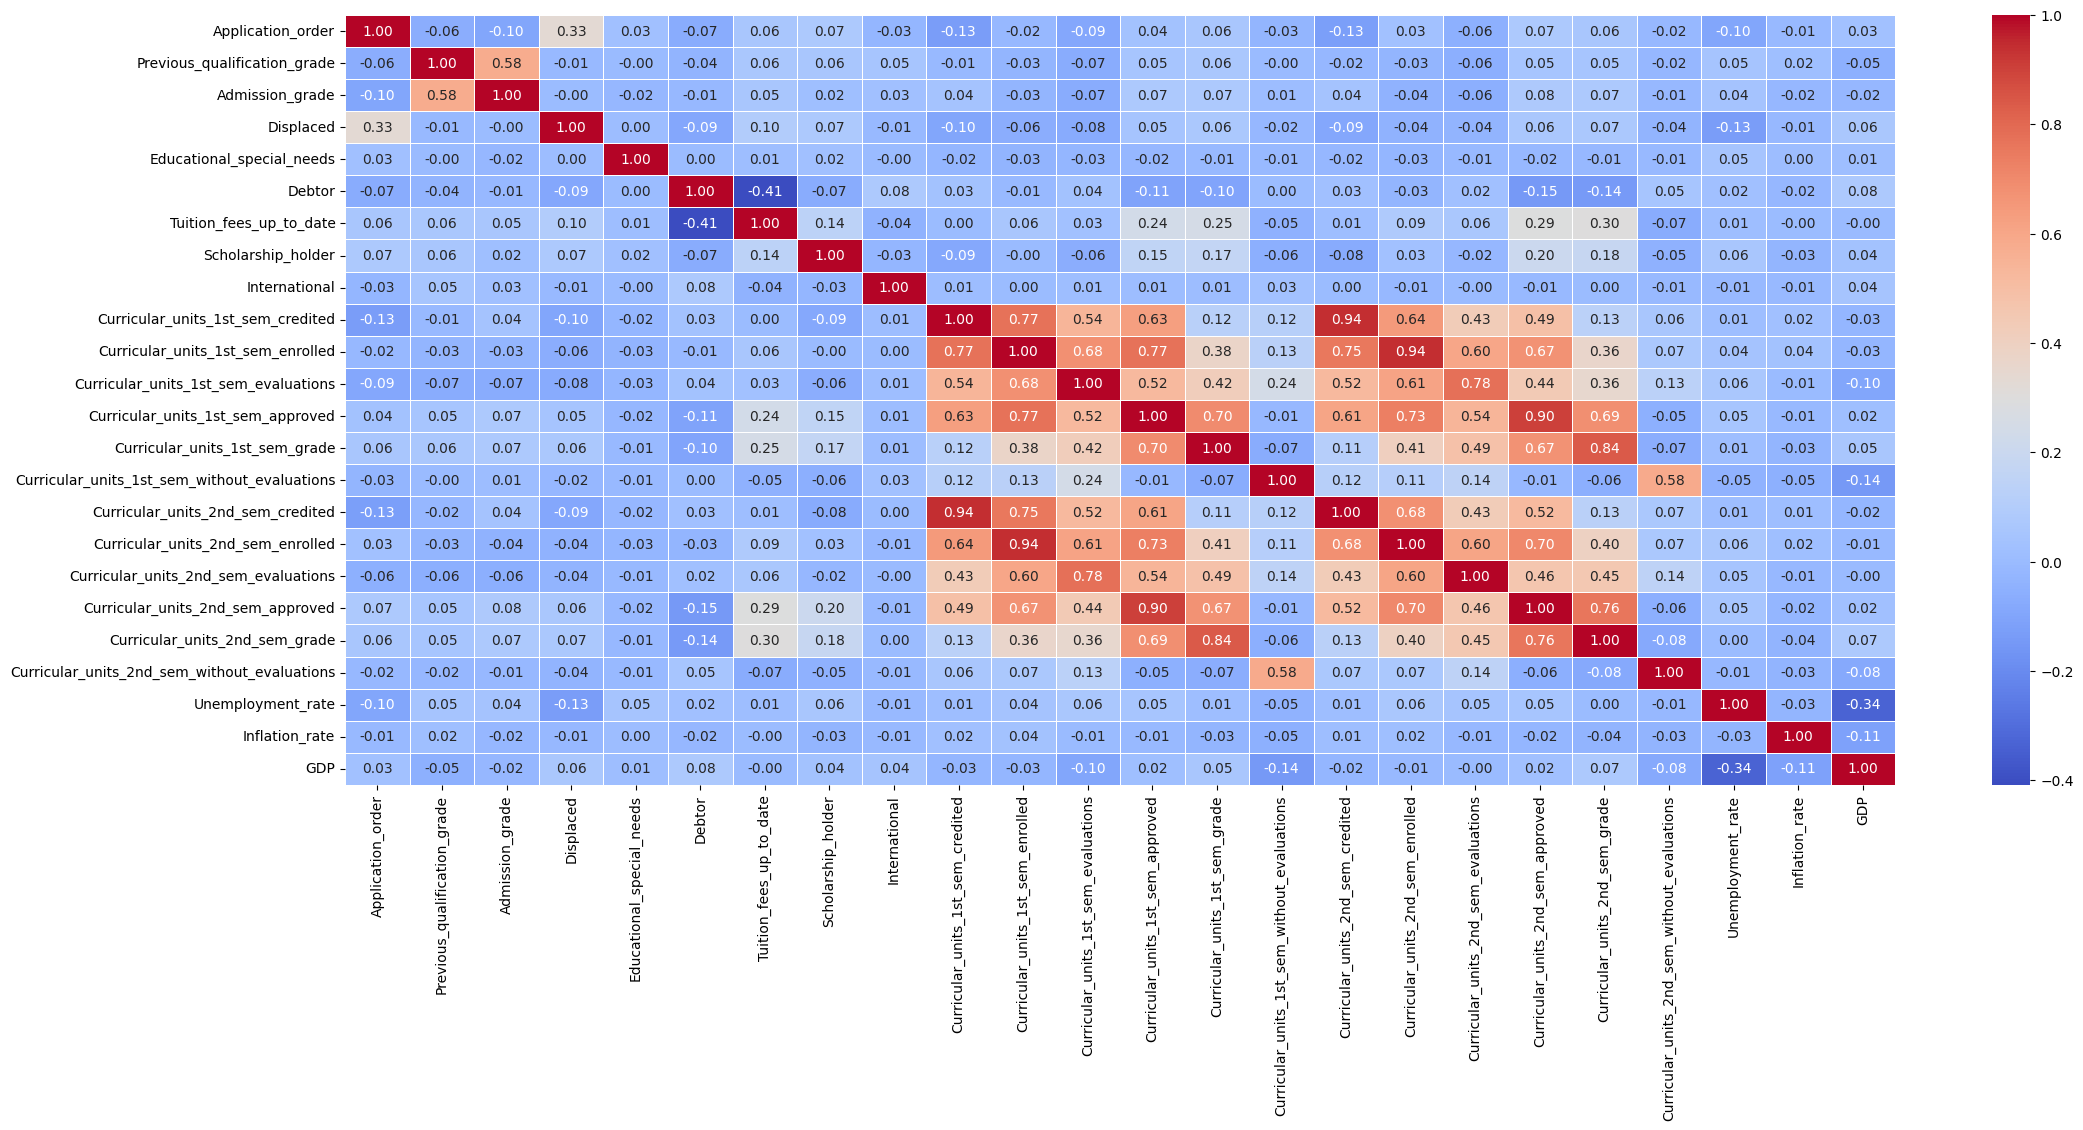

In [39]:
# Check correlation among numerical features
plt.figure(figsize=(25,10))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

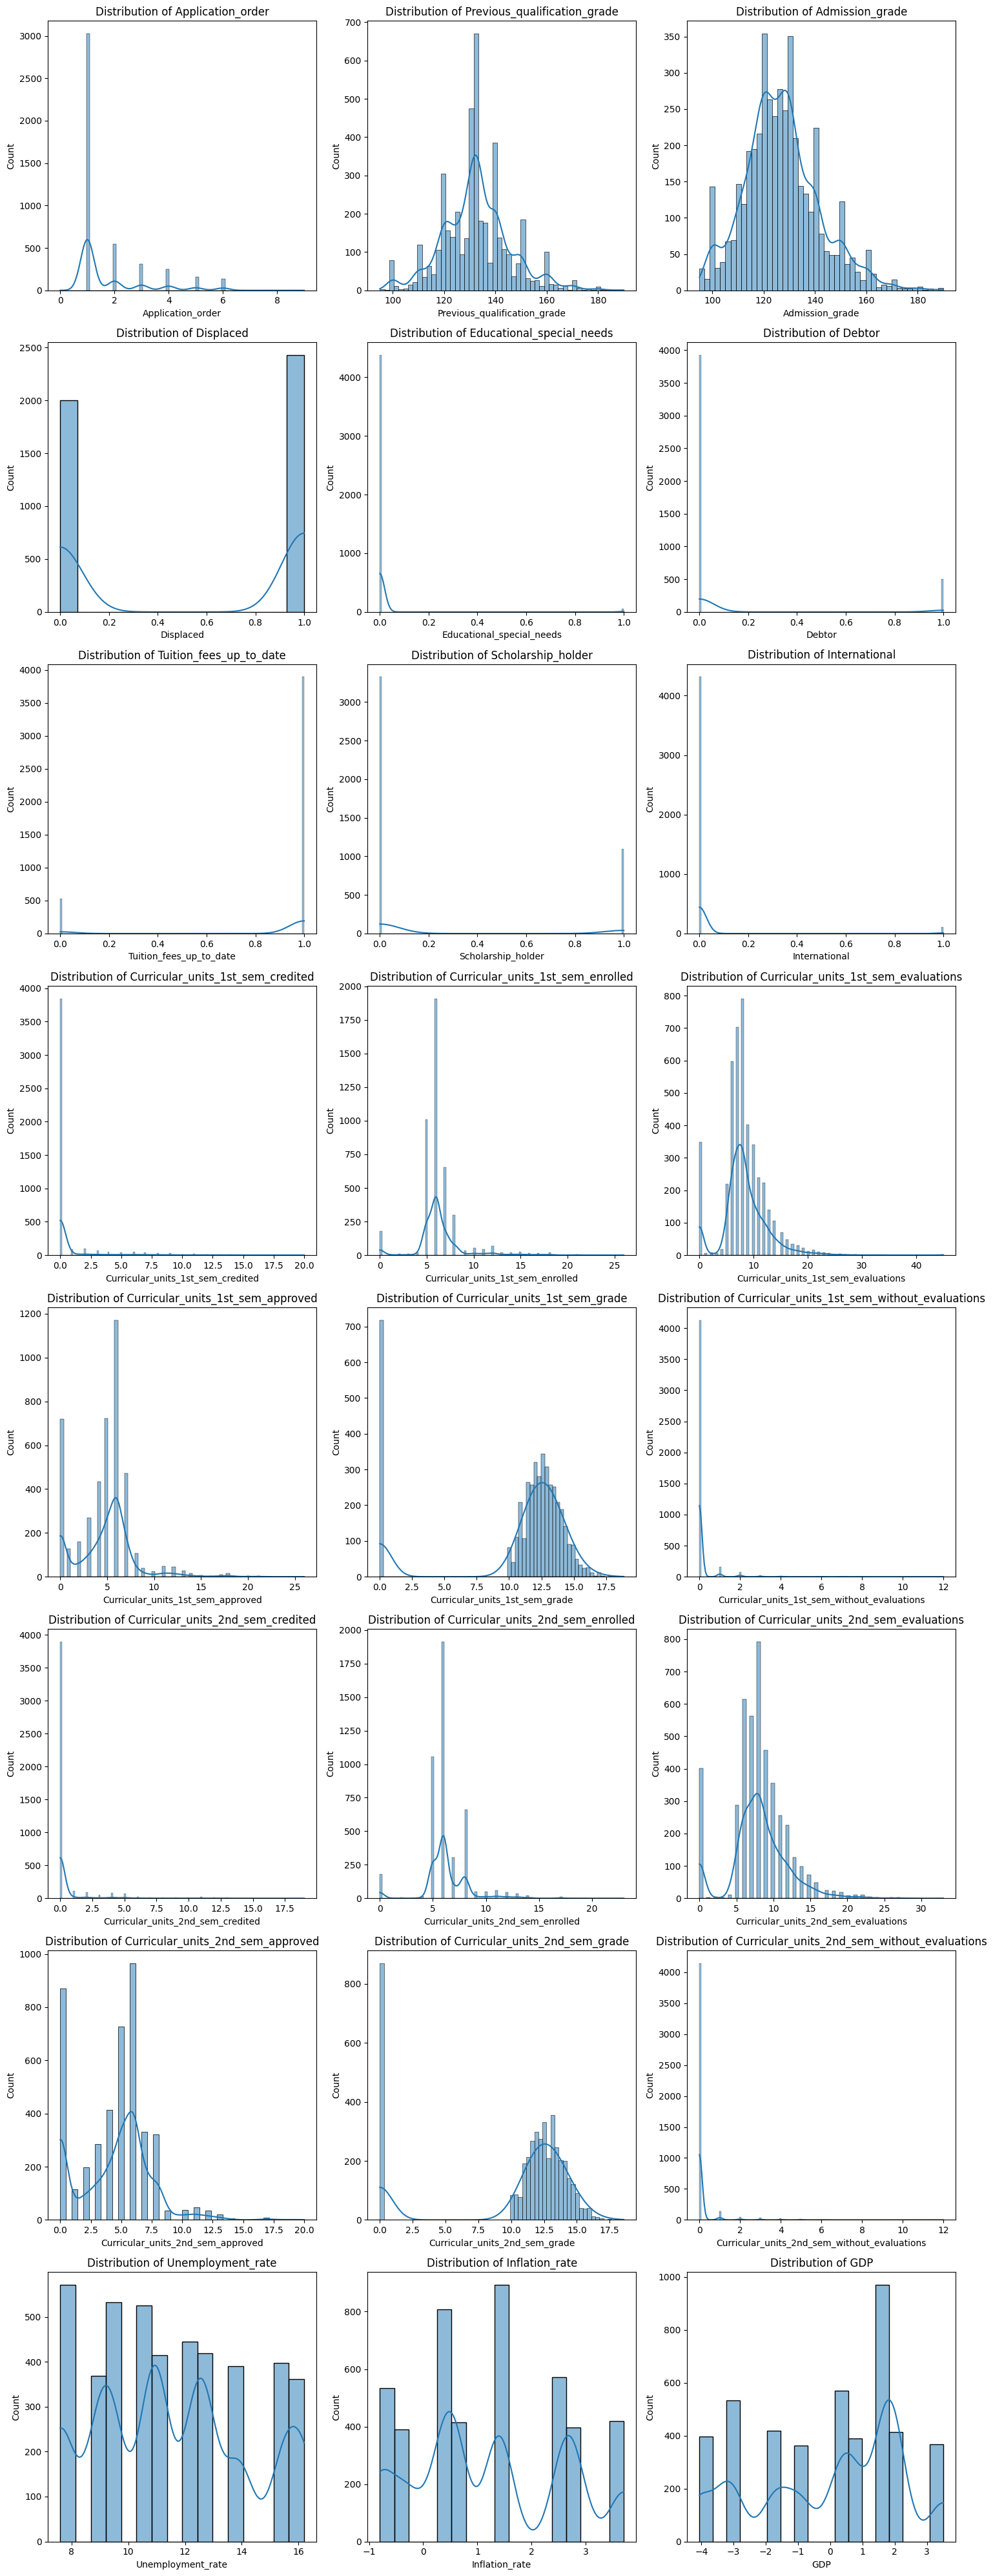

In [40]:
# Distribution feature numeric
n_feature = len(numerical_features)
n_col = 3
n_row = (n_feature + n_col - 1) // n_col

plt.figure(figsize=(15, 5 * n_row))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(n_row, n_col, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()


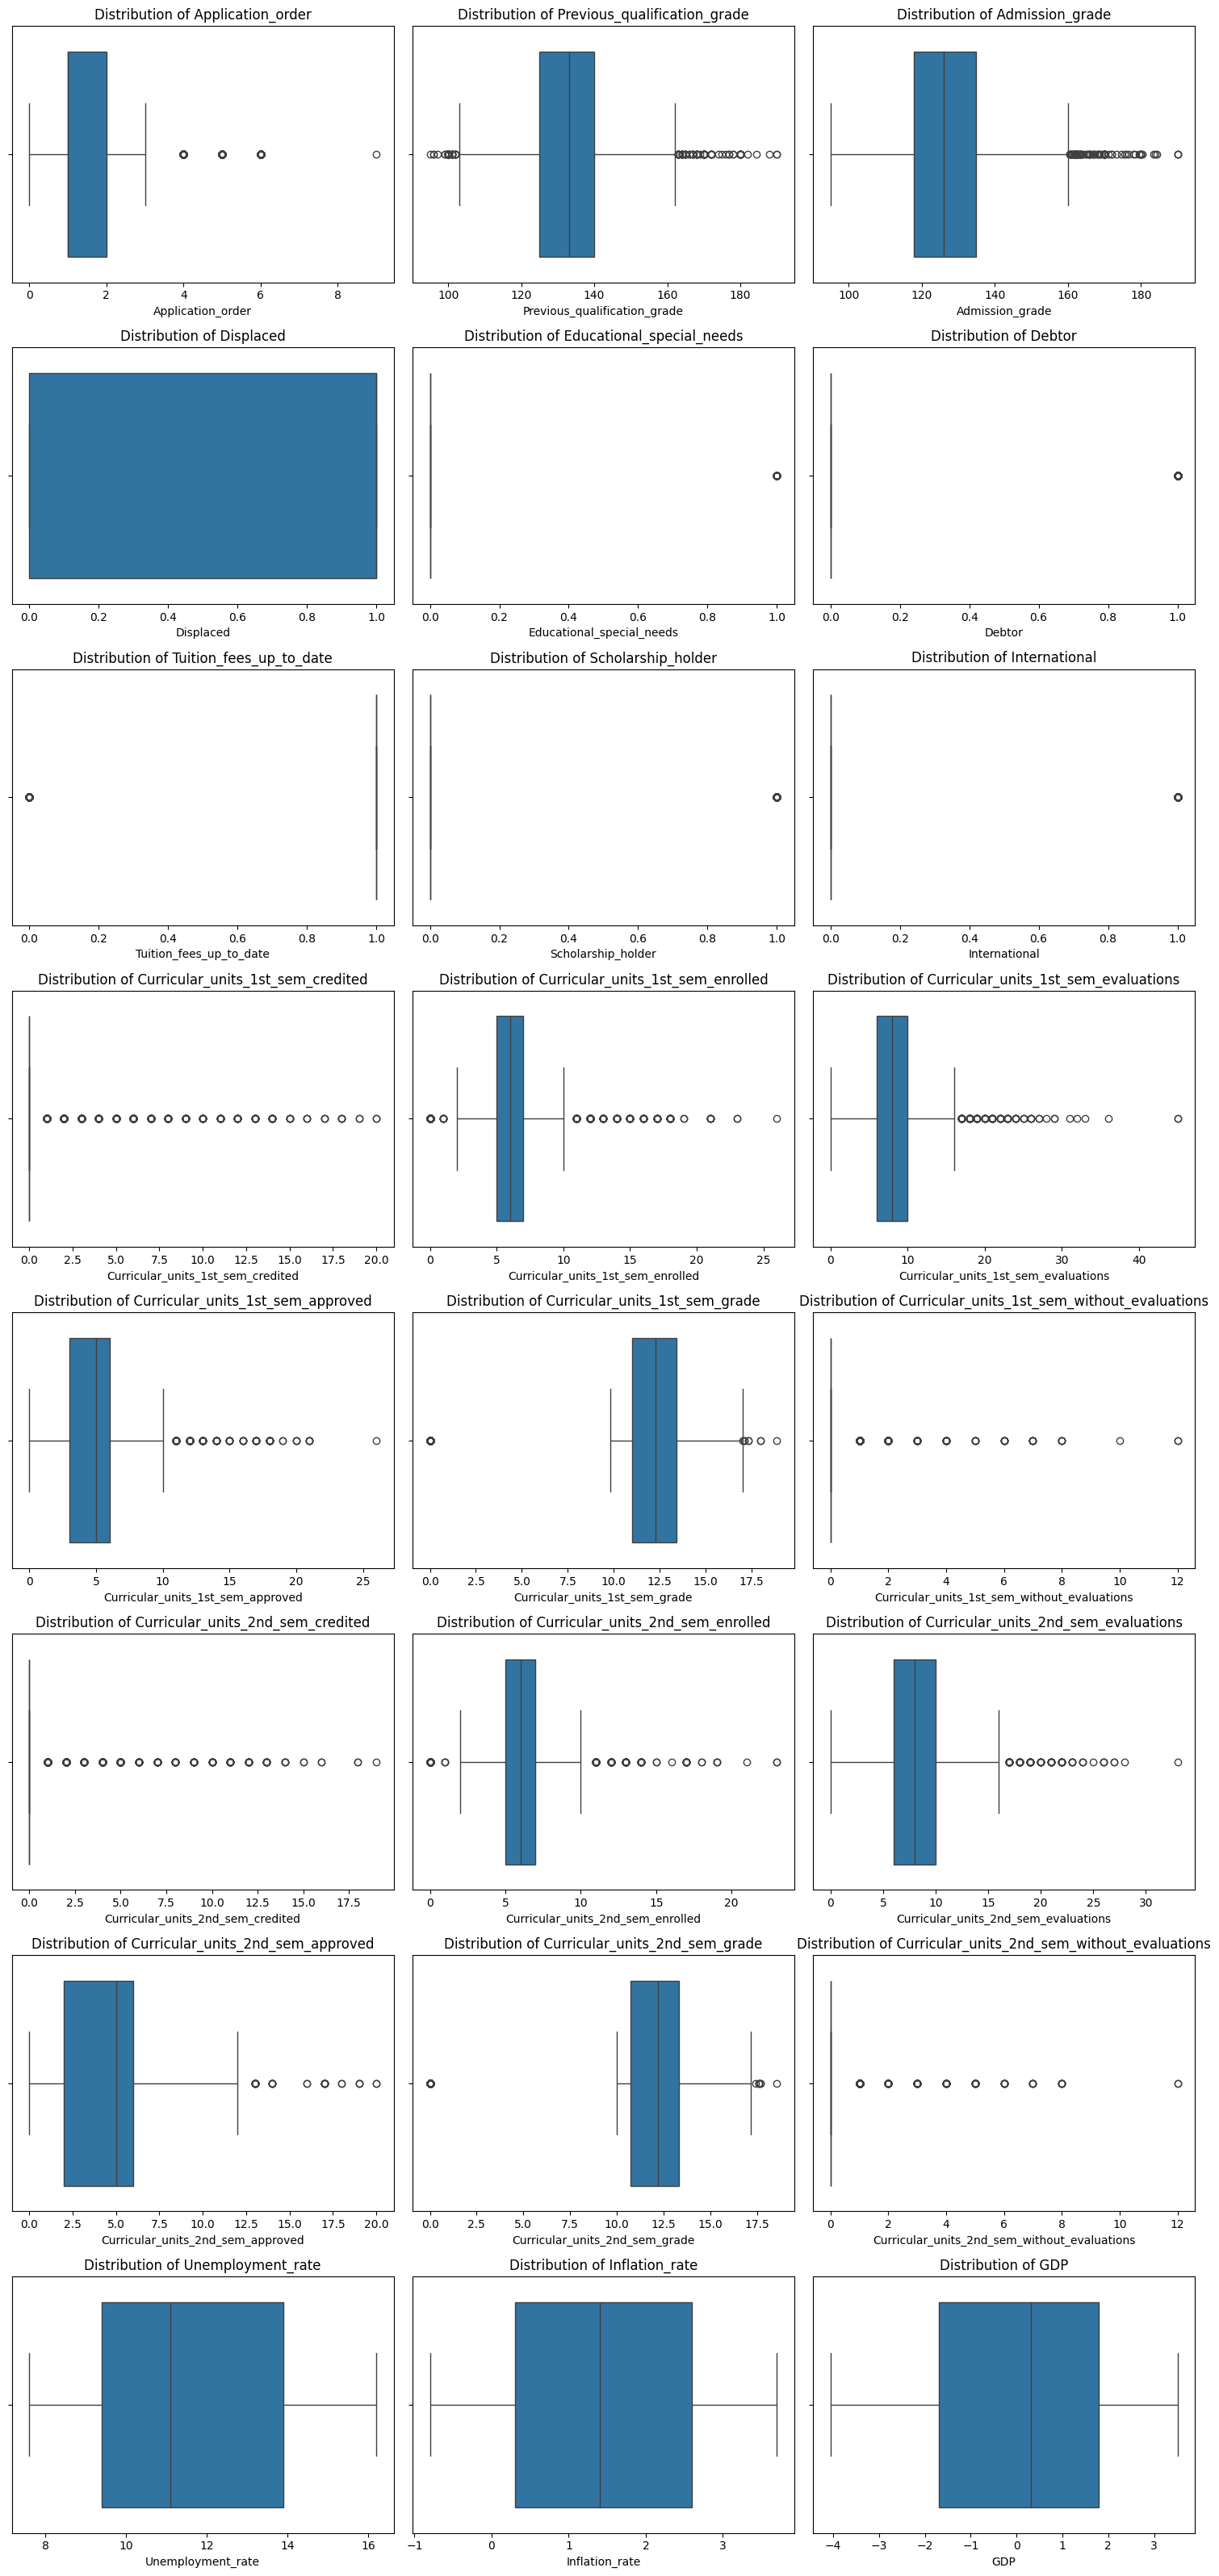

In [41]:
# Identify outliers in numerical features using box plots
n_cols = 3
n_features = len(numerical_features)
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

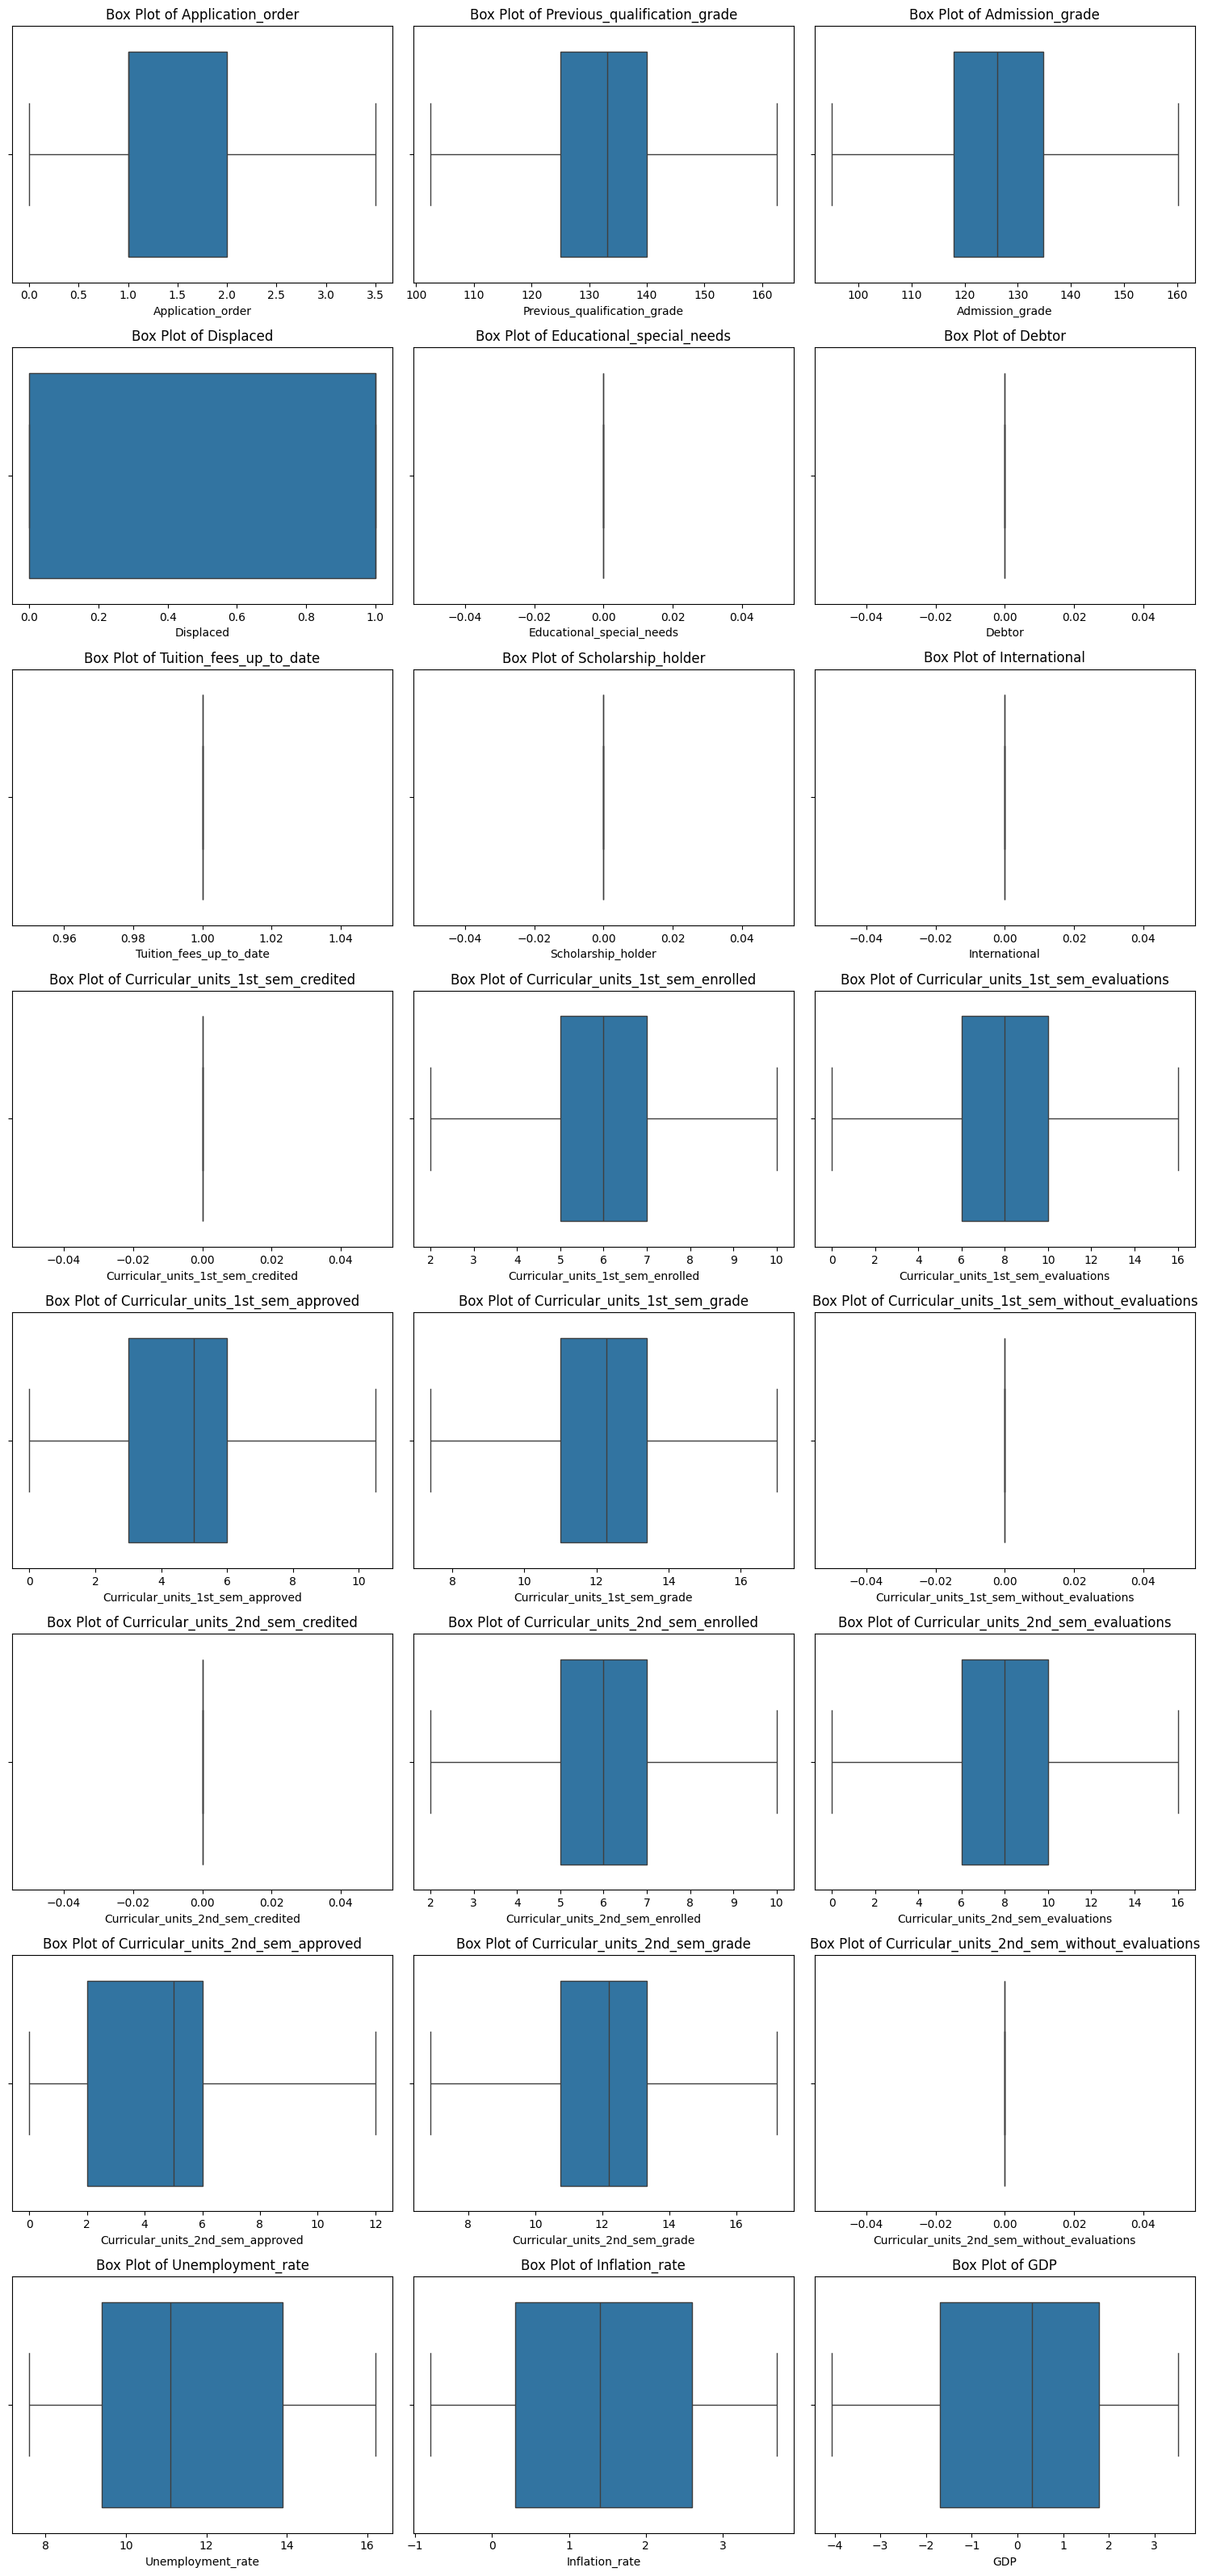

In [42]:
# ==============================================================================
# Handle outliers in numerical features using clipping
# ==============================================================================

# Calculate Q1, Q3, and IQR
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1

# Determine lower and upper bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Handle outliers using clipping method
df[numerical_features] = df[numerical_features].clip(lower=lower_bound, upper=upper_bound, axis=1)

# ======================================================================================
# BOX PLOT VISUALIZATION NUMERICAL FEATURES AFTER CLEANING OUTLIERS
# ======================================================================================

# Define grid layout configurations
n_cols = 3
n_features = len(numerical_features)
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()



In [43]:
# ==============================================================================
# FEATURE SCALING (STANDARDIZATION) for numerical_features
# ==============================================================================

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform only the defined numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df[numerical_features].head(5)

,Application_order,Previous_qualification_grade,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Scholarship_holder,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,2.102099,-0.834072,0.035097,0.907512,0.0,0.0,0.0,0.0,0.0,0.0,-2.627684,-2.215381,-1.681426,-1.923650,0.0,0.0,-2.644763,-2.165664,-1.511364,-1.786401,0.0,-0.287638,0.124386,0.765761
1,-0.619176,2.183947,1.121187,0.907512,0.0,0.0,0.0,0.0,0.0,0.0,-0.092546,-0.581725,0.519569,0.935356,0.0,0.0,-0.122982,-0.535428,0.546584,0.791523,0.0,0.876222,-1.105222,0.347199
2,2.102099,-0.834072,-0.143537,0.907512,0.0,0.0,0.0,0.0,0.0,0.0,-0.092546,-2.215381,-1.681426,-1.923650,0.0,0.0,-0.122982,-2.165664,-1.511364,-1.786401,0.0,-0.287638,0.124386,0.765761
3,0.469334,-0.834072,-0.515094,0.907512,0.0,0.0,0.0,0.0,0.0,0.0,-0.092546,-0.037173,0.519569,0.687823,0.0,0.0,-0.122982,0.551396,0.203593,0.310732,0.0,-0.813253,-1.466871,-1.375511
4,-0.619176,-2.382792,1.049734,-1.101914,0.0,0.0,0.0,0.0,0.0,0.0,-0.092546,0.235103,0.152736,0.213385,0.0,0.0,-0.122982,-0.535428,0.546584,0.538475,0.0,0.876222,-1.105222,0.347199


In [44]:
# Bining column Marital_status
bins_marital_status = [
    (df['Marital_status'] == 1),
    (df['Marital_status'].isin([2,5])),
    (df['Marital_status'].isin([3,4,6,7])),
]

labels_marital_status = ['Single', 'Married', 'Separated/Widowed']

df['Marital_status'] = np.select(
    bins_marital_status,
    labels_marital_status,
    default='Unknown'
)
df['Marital_status'].value_counts()

Marital_status
Single               3919
Married               404
Separated/Widowed     101
Name: count, dtype: int64

In [45]:
# Bining column Application_mode
bins_app_mode = [1,2,5,7,10,15,16,17,18,26,27,39,42,43,44,51,53,57,60]
labels_app_mode = [
    '1st phase - general contingent',
    'Ordinance No. 612/93',
    '1st phase - special contingent (Azores Island)',
    'Holders of other higher courses',
    'Ordinance No. 854-B/99',
    'International student (bachelor)',
    '1st phase - special contingent (Madeira Island)',
    '2nd phase - general contingent',
    '3rd phase - general contingent',
    'Ordinance No. 533-A/99, item b2) (Different Plan)',
    'Ordinance No. 533-A/99, item b3 (Other Institution)',
    'Over 23 years old',
    'Transfer',
    'Change of course',
    'Technological specialization diploma holders',
    'Change of institution/course',
    'Short cycle diploma holders',
    'Change of institution/course (International)'
]
df['Application_mode'] = pd.cut(df['Application_mode'], bins=bins_app_mode, labels=labels_app_mode, right=False)
df['Application_mode'].value_counts()

Application_mode
1st phase - general contingent                         1708
2nd phase - general contingent                          872
Over 23 years old                                       785
Change of course                                        312
Technological specialization diploma holders            213
Holders of other higher courses                         139
3rd phase - general contingent                          124
Transfer                                                 77
Change of institution/course                             59
1st phase - special contingent (Madeira Island)          38
Short cycle diploma holders                              35
International student (bachelor)                         30
1st phase - special contingent (Azores Island)           16
Ordinance No. 854-B/99                                   10
Ordinance No. 612/93                                      3
Ordinance No. 533-A/99, item b2) (Different Plan)         1
Ordinance No. 533-A/99,

In [46]:
# Bining column Course
bins_course = [33,171,8014,9003,9070,9085,9119,9130,9147,9238,9254,9500,9556,9670,9773,9853,9991,10000]
labels_course = [
    'Biofuel Production Technologies',
    'Animation and Multimedia Design',
    'Social Service (evening attendance)',
    'Agronomy',
    'Communication Design',
    'Veterinary Nursing',
    'Informatics Engineering',
    'Equinculture',
    'Management',
    'Social Service',
    'Tourism',
    'Nursing',
    'Oral Hygiene',
    'Advertising and Marketing Management',
    'Journalism and Communication',
    'Basic Education',
    'Management (evening attendance)'
]
df['Course'] = pd.cut(df['Course'], bins=bins_course, labels=labels_course, right=False)
df['Course'].value_counts()

Course
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Management (evening attendance)         268
Advertising and Marketing Management    268
Tourism                                 252
Communication Design                    226
Social Service (evening attendance)     215
Animation and Multimedia Design         215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equinculture                            141
Oral Hygiene                             86
Biofuel Production Technologies          12
Name: count, dtype: int64

In [47]:
# Transform Daytime_evening_attendance (1: DayTime, 0: Evening)
df['Daytime_evening_attendance'] = df['Daytime_evening_attendance'].apply(lambda x: 'DayTime' if x == 1 else 'Evening')
df['Daytime_evening_attendance'].value_counts()

Daytime_evening_attendance
DayTime    3941
Evening     483
Name: count, dtype: int64

In [48]:
# Transform Gender (1: Male, 0: Female)
df['Gender'] = df['Gender'].map({1: 'Male', 0: 'Female'})
df['Gender'].value_counts()

Gender
Female    2868
Male      1556
Name: count, dtype: int64

In [49]:
# Bining column Previous_qualification
bins_prev = [0,6,15,39,45]
labels_prev = ['Senior High School', 'Associate Degree', 'Bachelor Degree', 'Master Degree']
df['Previous_qualification'] = pd.cut(df['Previous_qualification'], bins=bins_prev, labels=labels_prev, right=True)

In [50]:
# Bining column Nacionality
bins_nacionality = [1,2,6,11,13,14,17,21,22,24,25,26,32,41,62,100,101,103,105,108,109,110]
labels_nacionality = ['Portuguese', 'German', 'Spanish', 'Italian', 'Dutch', 'English', 'Lithuanian',
                      'Angolan', 'Cape Verdean', 'Guinean', 'Mozambican', 'Santomean', 'Turkish',
                      'Brazilian', 'Romanian', 'Moldova (Republic of)', 'Mexican', 'Ukrainian', 'Russian',
                      'Cuban', 'Colombian'
                      ]
df['Nacionality'] = pd.cut(df['Nacionality'], bins=bins_nacionality, labels=labels_nacionality, right=False)
df['Nacionality'].value_counts()

Nacionality
Portuguese               4314
Brazilian                  38
Santomean                  14
Spanish                    13
Cape Verdean               13
Guinean                     5
Moldova (Republic of)       3
Italian                     3
Ukrainian                   3
Mexican                     2
German                      2
Mozambican                  2
Angolan                     2
Romanian                    2
Russian                     2
Dutch                       1
Lithuanian                  1
Turkish                     1
English                     1
Cuban                       1
Colombian                   1
Name: count, dtype: int64

In [51]:
# Bining coloumn Mothers_qualification
bins_mothers = [0,6,15,39,45]
labels_mothers = ['Senior High School', 'Associate Degree', 'Bachelor Degree', 'Master Degree']
df['Mothers_qualification'] = pd.cut(df['Mothers_qualification'], bins=bins_mothers, labels=labels_mothers, right=True)
df['Mothers_qualification'].value_counts()

Mothers_qualification
Bachelor Degree       2678
Senior High School    1664
Associate Degree        58
Master Degree           24
Name: count, dtype: int64

In [52]:
# Bining column Fathers_qualification
bins_fathers = [0,6,15,39,45]
labels_fathers = ['Senior High School', 'Associate Degree', 'Bachelor Degree', 'Master Degree']
df['Fathers_qualification'] = pd.cut(df['Fathers_qualification'], bins=bins_fathers, labels=labels_fathers, right=True)
df['Fathers_qualification'].value_counts()

Fathers_qualification
Bachelor Degree       3040
Senior High School    1313
Associate Degree        60
Master Degree           11
Name: count, dtype: int64

In [53]:
# Bining column Mother_occupation
bins_mother_occupation = [0,11,91,131,200]
labels_mother_occupation = ['Homemaker', 'Blue Collar', 'White Collar','Professional']
df['Mothers_occupation'] = pd.cut(df['Mothers_occupation'], bins=bins_mother_occupation, labels=labels_mother_occupation, right=False)
df['Mothers_occupation'].value_counts()

Mothers_occupation
Homemaker       4242
Professional      85
Blue Collar       70
White Collar      27
Name: count, dtype: int64

In [54]:
# Bining column Father_occupation
bins_father_occupation = [0,11,91,131,200]
labels_father_occupation = ['Professional', 'White Collar', 'Blue Collar','Unemployed']
df['Fathers_occupation'] = pd.cut(df['Fathers_occupation'], bins=bins_father_occupation, labels=labels_father_occupation, right=False)
df['Fathers_occupation'].value_counts()

Fathers_occupation
Professional    4247
Unemployed        76
White Collar      65
Blue Collar       36
Name: count, dtype: int64

In [55]:
# Bining column Age_at_enrollment
bins_age = [16, 26, 36, 46, 55, 70]
labels_age = ['17-25', '26-35', '36-45', '46-55', '55+']
df['Age_at_enrollment'] = pd.cut(df['Age_at_enrollment'], bins=bins_age, labels=labels_age, right=True)
df['Age_at_enrollment'].value_counts()

Age_at_enrollment
17-25    3473
26-35     594
36-45     256
46-55      88
55+        13
Name: count, dtype: int64

In [56]:
# Define label encoding the 'Status' column into numerical values
label_encoder = LabelEncoder()
df['Status'] = label_encoder.fit_transform(df['Status'])

In [57]:
# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform
encode_arr = encoder.fit_transform(df[categorical_features])

# Generate new column names
encode_cols = encoder.get_feature_names_out(categorical_features)

# Convert to DataFrame
encode_categorical = pd.DataFrame(encode_arr, columns=encode_cols, index=df.index)

# Drop categorical_features
df = df.drop(columns=categorical_features)

# Concatenate new categorical features
df = pd.concat([df, encode_categorical], axis=1)


In [58]:
# Review the number of rows, columns, and data types of dataset (df)
df.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 114 columns):
 #    Column                                                                Non-Null Count  Dtype  
---   ------                                                                --------------  -----  
 0    Student_ID                                                            4424 non-null   int64  
 1    Application_order                                                     4424 non-null   float64
 2    Previous_qualification_grade                                          4424 non-null   float64
 3    Admission_grade                                                       4424 non-null   float64
 4    Displaced                                                             4424 non-null   float64
 5    Educational_special_needs                                             4424 non-null   float64
 6    Debtor                                                                4424 non-null   